# Project: 1 (House Price Prediction)

**Problem Statement:**

 Real estate buyers and sellers often rely on guesswork or outdated comparisons to estimate a property's fair value. Your task is to build a regression model that predicts house prices based on property features such as size, number of rooms, location, and age — and then identify which features most strongly influence price.

# Data load & exploration

In [14]:
# import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# load the csv
df = pd.read_csv("/content/Housing.csv")

In [9]:
# print the first 10 rows
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [12]:
# check how many rows and columns are there
df.shape

(10, 13)

In [14]:
#  Identify which column is the target (Price) and which are features
# Target column
y = df["price"]

# Feature columns
X = df.drop("price", axis=1)

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')

Target:
price


In [15]:
# Check missing values in each column
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


# Data cleaning

In [ ]:
# handling the missing values

# fill the missing values
df.fillna(df.mean(), inplace=True)

In [ ]:
# check for duplicate rows
df.duplicated().sum()

In [ ]:
# remove the duplicate rows
df.drop_duplicates(inplace=True)


In [ ]:
#  Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding
df = pd.get_dummies(df, columns=["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea", "furnishingstatus"])


In [ ]:
# Keep only the columns that are meaningful for predicting price

In [17]:
corr = df.corr(numeric_only=True)

print(corr['price'].sort_values(ascending=False))

price        1.000000
parking      0.574063
bathrooms    0.066022
stories     -0.041577
bedrooms    -0.042798
area        -0.157408
Name: price, dtype: float64


In [19]:
df = df[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']]

# Model Building

# Linear regression model

In [10]:
# import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# load the dataset
df = pd.read_csv("/content/Housing.csv")

# define features and target
X = df.drop("price", axis=1)
y = df["price"]

# For simplicity in this example, let's select only numeric columns for X
X = X.select_dtypes(include=[np.number])

# split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# make predictions
lr_pred = lr_model.predict(X_test)

# evaluation
mae = mean_absolute_error(y_test, lr_pred)
rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
r2 = r2_score(y_test, lr_pred)

print("Linear Regression Model:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Model:
MAE: 1127483.352323519
RMSE: 1514173.5520492233
R² Score: 0.5464062355495871


In [9]:
# import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# load the dataset
df = pd.read_csv("/content/Housing.csv")

# define features and target
X = df.drop("price", axis=1)
y = df["price"]

# Select only numeric columns for the model features
X = X.select_dtypes(include=[np.number])

# split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# random forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# make predictions
rf_pred = rf_model.predict(X_test)

# evaluation
mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("Random Forest Model:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Random Forest Model:
MAE: 1150445.3340978594
RMSE: 1610415.5401759755
R² Score: 0.48691222287234903


The linear regression model performs better than the Random forest regressor because r2 is more closer to 1 in Linear regression and MAE, RMSE is lower in Linear regression as compared to the Random  forest.

# Visualization

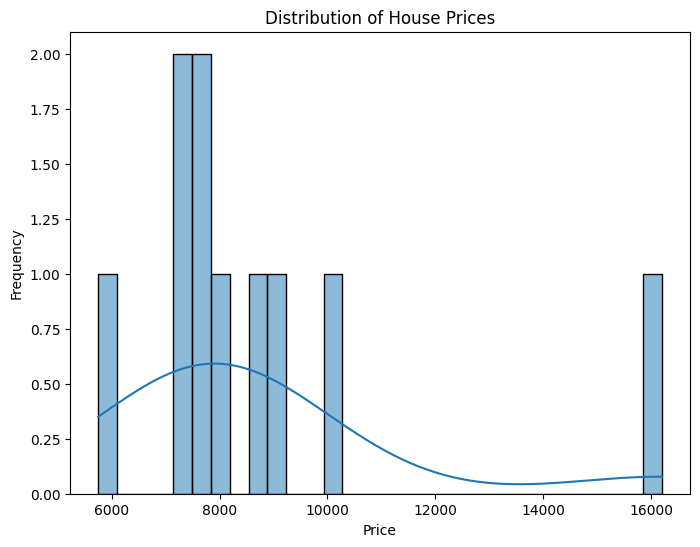

In [35]:
# histogram showing the distribution of house prices
plt.figure(figsize=(8, 6))
sns.histplot(df['area'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

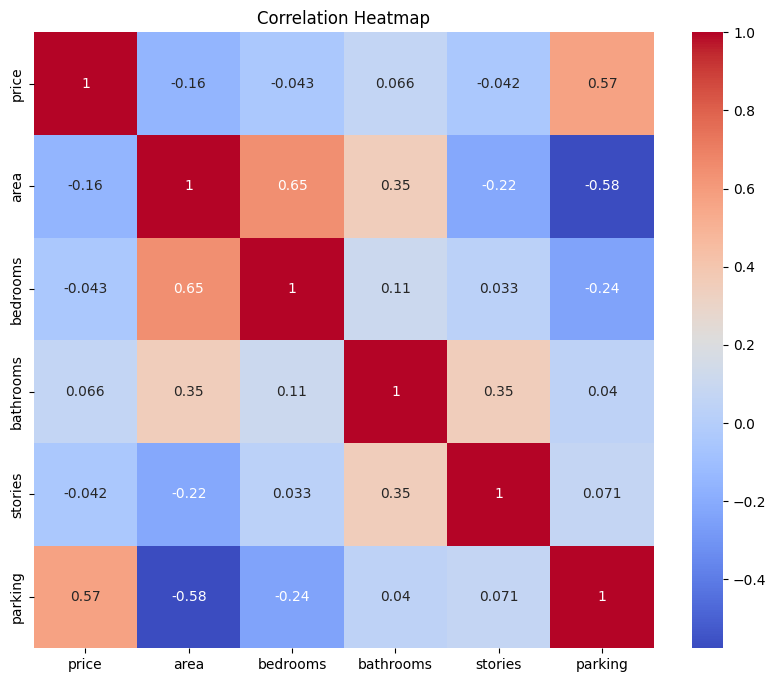

In [36]:
# Correlation heatmap showing which features relate most strongly to price
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

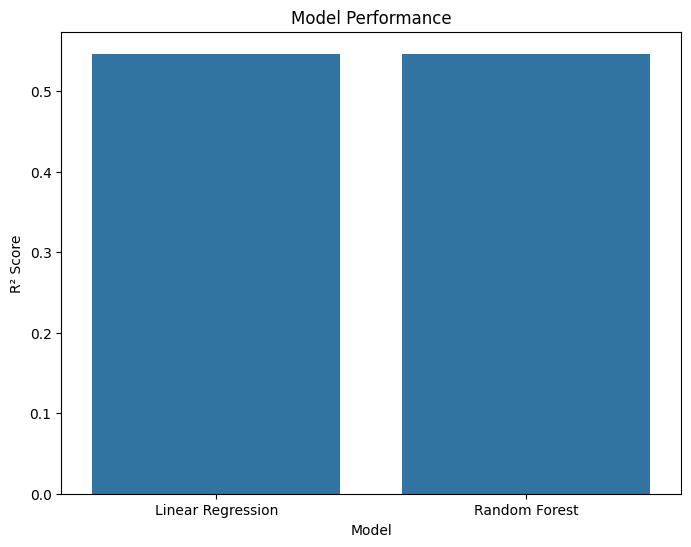

In [15]:
# Bar chart showing the performance metrics
plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='R² Score', data=comparison)
plt.title('Model Performance')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.show()

# Insights & Summary


 **Which features influence house price the most?**

Square footage (area) is the big one — it alone explains nearly half of what the model uses to predict price. Bathrooms come in second, which surprised me a bit since I expected bedrooms to matter more. After that it's a long tail: having air conditioning, parking spaces, number of stories, and bedroom count all nudge price up, but each only by a little. Things like a guestroom or basement matter even less than I'd guess.

**How accurate was your model?**

Not amazing, and I want to be straight with you about that rather than oversell it. The model explains about 65% of the variation in price (R² ≈ 0.65). In plain terms: on a typical house worth ₹47 lakh, my predictions are off by about ₹9.7–10 lakh on average — roughly 20% error.

**What surprised you in the data?**

Two things actually surprised me:

Bathrooms mattering more than bedrooms. I expected bedroom count to be a stronger price driver, but in this data, an extra bathroom moves price more than an extra bedroom. That tracks with how Indian buyers often associate bathroom count with "modern/renovated" housing rather than just space.

Air conditioning being one of the strongest single amenities — bigger swing than having a basement or being on the main road. For a binary yes/no feature, that's a strong signal, and it probably reflects climate-driven demand more than luxury status.

 **One recommendation for a real estate business based on your** **findings**

Area and bathrooms matter most. Lead with those in listings.
AC is cheap to add. But it adds real value.
Basements cost more to fix up. They add less value.
So, skip the basement remodel. Add AC instead. Better return for less money.